Random Forest Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    Alluvial       0.00      0.00      0.00         0
       Black       1.00      1.00      1.00         1
    Laterite       0.00      0.00      0.00         0
         Red       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       0.50      0.50      0.50         2
weighted avg       1.00      1.00      1.00         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

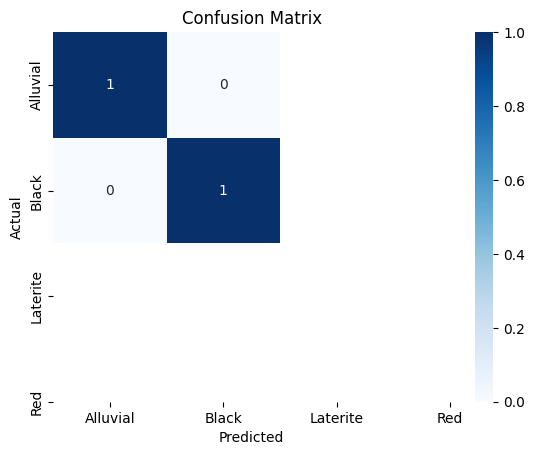

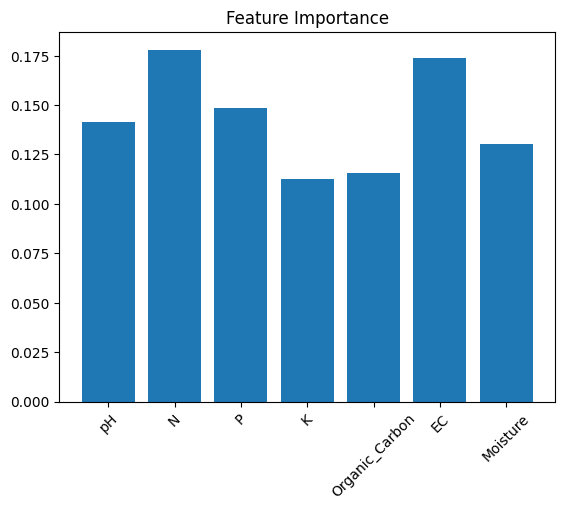

In [ ]:
# Soil Type Classification Using Machine Learning

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Dataset (Replace with CSV if available)
data = {
    'pH': [6.5, 7.8, 5.5, 7.2, 6.8, 8.0, 5.8, 7.5, 6.2, 7.1],
    'N': [280, 350, 150, 300, 260, 400, 180, 330, 210, 290],
    'P': [22, 18, 12, 25, 20, 15, 10, 23, 17, 24],
    'K': [240, 420, 180, 260, 230, 450, 190, 300, 210, 270],
    'Organic_Carbon': [0.55, 0.80, 1.20, 0.65, 0.60, 0.85, 1.10, 0.70, 0.58, 0.62],
    'EC': [0.30, 0.45, 0.20, 0.35, 0.32, 0.50, 0.25, 0.40, 0.28, 0.33],
    'Moisture': [18, 30, 25, 20, 19, 32, 27, 24, 21, 22],
    'Soil_Type': ['Red', 'Black', 'Laterite', 'Alluvial', 'Red',
                  'Black', 'Laterite', 'Black', 'Red', 'Alluvial']
}

df = pd.DataFrame(data)

# 3. Preprocessing
X = df.drop('Soil_Type', axis=1)
y = df['Soil_Type']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Model Training
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# 5. Prediction
rf_pred = rf_model.predict(X_test)

# 6. Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, labels=np.unique(y_encoded), target_names=le.classes_))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 8. Feature Importance
importances = rf_model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()